In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from tqdm.auto import tqdm

**See first:** [Video: gentle introduction](https://www.youtube.com/watch?v=jmmW0F0biz0), [Video: introduction to neural networks](https://www.youtube.com/watch?v=xx1hS1EQLNw), [What is a neural network](https://www.geeksforgeeks.org/machine-learning/neural-networks-a-beginners-guide/)

## Physics-informed neural networks (PINNs)

Physics-informed neural networks (PINNs) try to reconcile observations with a model of the system (e.g., an ODE).

### PINNs in a nutshell

Roughly speaking, a PINN can be thought of as a **maximum a posteriori estimation** problem where the fact that $\dot{x} = f(x; \theta)$ is treated as prior knowledge (here $\theta$ is the parameter vector to be estimated). A neural network is used to describe the system states and outputs. Again roughly speaking, think of 
$$x(t) = \mathrm{NeuralNetwork}(t; \theta).$$

This is convenient because $y$ can be differentiated wrt $t$ using automatic differentiation.

We can then define an ODE loss function, which may look like 
$$\mathcal{L}_{\rm ode}(\theta) = \frac{1}{N}\sum_{i} (\dot{x}(t_i) - f(x(t_i)))^2,$$
given points $(t_i)_i$. The derivative $\dot{x}$ is the derivative of a neural network.

At the same time we define the measurement loss, which is 
$$\mathcal{L}_{\rm meas}(\theta) = \sum_{j} ( y(t_j; b) - y^{\rm meas}(t_j) )^2.$$

The overall loss function is a combination of the ODE loss and the measurement loss, e.g.,
$$\mathcal{L}(\theta) = \mathcal{L}_{\rm ode}(\theta) + \lambda \mathcal{L}_{\rm meas}(\theta),$$
for some $\lambda > 0$.


### Applications of PINNs

PINNs are useful when observations are sparse or noisy: the physical model constrains the range of plausible solutions and can improve predictions between measurement points. PINNs can also solve *inverse problems*, in which unknown physical parameters are learned from data alongside the system response.

In this notebook, a neural network approximates the displacement $\hat{y}(t)$ of a spring–mass–damper system. We compute its first and second time derivatives using PyTorch, then train it with a loss combining the ODE residual and the discrepancy from noisy displacement observations. The mass $m$ and spring constant $k$ are treated as known, while the trajectory and damping coefficient $b$ are inferred. Finally, we compare the learned trajectory with the exact solution and examine the convergence of the losses and the estimate of $b$.


### Reading material

A good starting point is the book "Data-driven science and engineering: Machine learning, dynamical system, and control," by S. Brunton and J. Kutz, 2nd ed., Cambridge University Press, 2022. You can also find plenty of Python notebooks on PINNs in the online [Physics-based Deep Learning book](https://github.com/tum-pbs/pbdl-book/tree/main) by Thuerey et al.



## Spring-Mass-Damper System

### System dynamics

Consider the following spring-mass-damper system

<img src="../images/spring-mass-damper.png" width="250"/>

Let $\bar{x}$ be the rest position of the mass and define $y = x - \bar{x}$. The equation of motion in terms of $y$ is
$$m\ddot{y} + b\dot{y} + ky = 0.$$
Suppose that the initial conditions are $y(0) = y_0$ and $\dot{y}(0) = v_0$. This is a simple dynamical system and the solution is available as a closed-form expression.

### Exact solution

Suppose also that $b^2 < 4mk$. In this case, the system is underdamped and exhibits a natural oscillatory behaviour. The solution of the above initial value problem is
$$y(t) = e^{-\frac{b}{2m}t}\left(y_0 \cos(\omega t) + c\sin(\omega t)\right),$$
where
$$\omega = \frac{\sqrt{4mk - b^2}}{2m}, c = \frac{v_0 + \frac{by_0}{2m}}{\omega}.$$
Below we implement `spring_solution`, which computes $y(t; m, b, k, y_0, v_0)$.

In [14]:
def spring_solution(t, m_, b_, k_, y0_, v0_):
    a = b_ / (2 * m_)
    discriminant = torch.as_tensor(4*m_*k_ - b_**2, dtype=t.dtype, device=t.device)
    omg = torch.sqrt(discriminant) / (2*m_)
    c = (v0_ + a*y0_) / omg
    return torch.exp(-a*t) * (y0_ * torch.cos(omg * t) + c * torch.sin(omg * t))

Note that in this case we have the closed-form solution of the system. This is hardly ever the case in practice. Typically, we need to discretise the differential equation using a [Runge-Kutta method](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods), or a similar discretisation method. This is done in the [next Python notebook](./2_pinn.ipynb).

### Problem statement

Suppose we know $m$ and $k$, but we don't know the value of $b$. We will estimate jointly the parameter $b$ and the system response using noisy measurements of $y$. The initial conditions, $y(0)$ and $v(0)$, are not considered to be known and no prior information about them is available.

## Neural Network

We will approximate the solution, $y(t)$, by a [fully-connected neural network](https://www.geeksforgeeks.org/deep-learning/what-is-fully-connected-layer-in-deep-learning/) with linear layers and the smooth hyperbolic tangent activation function.

<img src="../images/nn.png" width="300"/>

With this NN we seek to approximate the solution of the ODE. The input will be the time $t$, scaled to $[-1,1]$ before being passed to the network, and the output will be an approximation $\hat{y}(t) \approx y(t)$.

Next, we introduce the class `FullyConnectedNN`, which is a fully-connected neural network. This construct is pretty standard in torch.

📝 Note that the neural network takes in a *scaled time* in $[-1, 1]$ (this works well with the hyperbolic tangent function). The original time variable takes values in $[0, 1]$, so the scaled time is $t' = 2t - 1$.


In [15]:
class FullyConnectedNN(nn.Module):

    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        n_hidden_layers = len(hidden_layers)
        in_ = 1
        for i in range(n_hidden_layers):
            out_ = hidden_layers[i]
            layer_ = nn.Sequential(nn.Linear(in_, out_), nn.Tanh())
            in_ = out_
            layers.append(layer_)
        layers.append(nn.Linear(in_, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        scaled_time = 2.0 * t - 1.0
        return self.net(scaled_time)


**Question:** What is the number of parameters of the network `FullyConnectedNN(hidden_layers=[32, 64])`?

In [16]:
# Your code goes here
hidden_layers = [32, 64]
model = FullyConnectedNN(hidden_layers=hidden_layers)
params = model.parameters()
num_params = sum(p.numel() for p in params)

print(f"A model with {hidden_layers} layers has {num_params} parameters")

A model with [32, 64] layers has 2241 parameters


## Data generation

Here we create some synthetic data using the above system. We use the values $m=1$, $k=250$, and $b=4$. We use the initial conditions $y_0 = 1.5$ and $v_0 = 5$. The following block of code computes $y(t)$ for $t\in [0, 1]$. The output of the system is corrupted by normal additive noise of a given variance. 

A total of `n_observations` measurements is obtained. These data points will be used afterwards in PINN training.

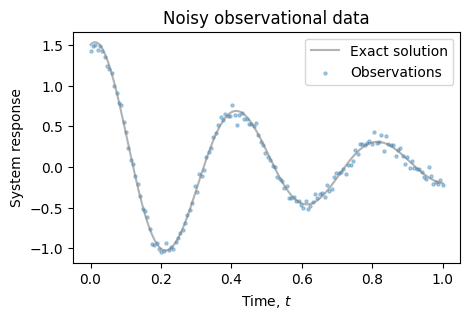

In [17]:
# first, create some noisy observational data
torch.manual_seed(1)

# Parameters
m = 1 # mass
b = 4 # damping coeff
k = 250 # spring constant
y0 = 1.5 # initial displacement
v0 = 5 # initial velocity

# Exact solution
t_test = torch.linspace(0, 1, 300).view(-1, 1)
u_exact = spring_solution(t_test, m, b, k, y0, v0)

# Noisy Observations
n_observations = 150
noise_level = 0.05
t_obs = torch.linspace(0,1,n_observations).view(-1,1)
u_obs = spring_solution(t_obs, m, b, k, y0, v0) + noise_level * torch.randn_like(t_obs)

plt.figure(figsize=(5,3))
plt.title("Noisy observational data")
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.scatter(t_obs[:,0], u_obs[:,0], label="Observations", alpha=0.35, s=5)
plt.xlabel("Time, $t$")
plt.ylabel("System response")
plt.legend()
plt.show()

## Loss function

The parameter we want to estimate here is $\theta = b$. The loss function we will aim to minimise is
$$
\mathcal{L}(\theta)
{}={}
\underbrace{\frac{1}{N} \sum^{N}_{i} \left( \left[ m\frac{{\rm d}^2}{{\rm d}t^2} + b \frac{{\rm d}}{{\rm d}t} + k \right] \hat{y}(t_{i};\theta) \right)^2}_{\text{ODE loss}}
{}+{}
\lambda_1\underbrace{\frac{1}{M} \sum^{M}_{j} \left( \hat{y}(t_{j};\theta) - y_{\mathrm{obs}}(t_{j})\right)^2}_{\text{Obervation loss}}
$$

In [18]:
def lossfun(pinn_model, t_physics_, t_observations_, u_observations_, lambda_obs_, m_, b_, k_):
    # ODE loss
    u_t_physics = pinn_model(t_physics_)
    dudt = torch.autograd.grad(u_t_physics, t_physics_, torch.ones_like(u_t_physics), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics_, torch.ones_like(dudt), create_graph=True)[0]
    loss_ode = torch.mean((m_ * d2udt2 + b_ * dudt + k_ * u_t_physics)**2)
    # Observations loss
    u_t_obs_ = pinn_model(t_observations_)
    loss_observations = torch.mean((u_t_obs_ - u_observations_)**2)
    # Total loss
    total_loss = loss_ode + lambda_obs_ * loss_observations
    return total_loss, loss_ode, loss_observations

⚠️ No prior information on $b$ has been provided. It is even possible that the estimated value will be negative, which is of course not meaningful. Thankfully, as we'll see in a moment, this doesn't happen, but it is good practice to enforce positivity of $b$; we will address this in [next Python notebook](./2_pinn.ipynb).

❓Quick question: suppose we had the prior information that "$y(0)$ is close to $1.5$". How would you change the loss function to include this information?

## Model training

<details>
<summary>Should I use a large NN?</summary>

A larger network can

- represent oscillations more accurately;
- reduce approximation error;
- sometimes converge faster.

But it can also

- take longer to train
- become very sensitive to a bad model (e.g., suppose $m$ is misestimated)
- end up "modelling" measurement noise
- produce less reliable second derivatives
- make physical-parameter identification worse even when the trajectory looks better.
</details>

In [19]:
torch.manual_seed(1)
pinn = FullyConnectedNN([32, 64, 32])
pinn.train() # preparation for training

t_physics = torch.linspace(0, 1, 50).view(-1,1).requires_grad_(True)
lam = 1500
n_epochs = 80000

# Optimise using Adam
b_param = nn.Parameter(torch.zeros(1, requires_grad=True))
b_cache, loss_cache = torch.zeros(n_epochs), torch.zeros((n_epochs, 3))
optimiser = torch.optim.Adam( 
    list(pinn.parameters()) + [b_param], 
    lr=5e-4, 
    betas=(0.98, 0.9995), 
    amsgrad=True)

for i in tqdm(range(n_epochs), desc="Training PINN"):
    loss, loss_ode, loss_obs = lossfun(pinn, t_physics, t_obs, u_obs, lam, m, b_param, k)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    b_cache[i] = b_param.item(); loss_cache[i, :] = torch.tensor([ loss.item(), loss_ode.item(), lam*loss_obs.item()])

Training PINN:   0%|          | 0/80000 [00:00<?, ?it/s]

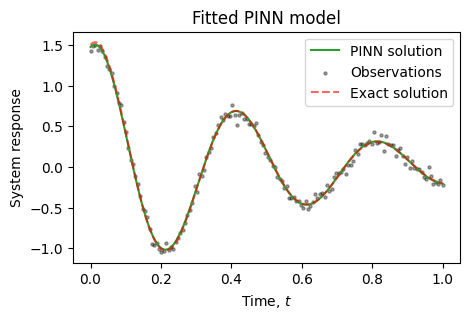

In [20]:
pinn.eval()
with torch.no_grad():
    u = pinn(t_test)
plt.figure(figsize=(5, 3))
plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
plt.scatter(t_obs[:,0], u_obs[:,0], color='black', label="Observations", alpha=0.35, s=5)
plt.plot(t_test[:,0], u_exact[:,0], 'r--', label="Exact solution", alpha=0.6)
plt.title("Fitted PINN model")
plt.xlabel("Time, $t$")
plt.ylabel("System response")
plt.legend()
plt.show()

To measure the distance of the estimated PINN-based solution, $\hat{y}$, from the exact solution, $y$, we can compute the RMSE of their difference, that is
$${\rm rmse} = \sqrt{\int_0^1 (y(t) - \hat{y}(t))^2 {\rm d}t}$$

In [21]:
integral = 0.0

for i in range(t_test.shape[0] - 1):
    # Integration using the trapezoid rule 
    e_left = (u_exact[i] - u[i])**2
    e_right = (u_exact[i + 1] - u[i + 1])**2
    dt = t_test[i + 1] - t_test[i]
    integral += 0.5 * (e_left + e_right) * dt

rmse = torch.sqrt(integral)

print(f"RMSE = {rmse.item():.3f}")

RMSE = 0.010


Next, let us plot the estimated value of $b$ against the training epochs. This shows whether we have taken a sufficient number of epochs for the estimate to (approximately) settle to a value.

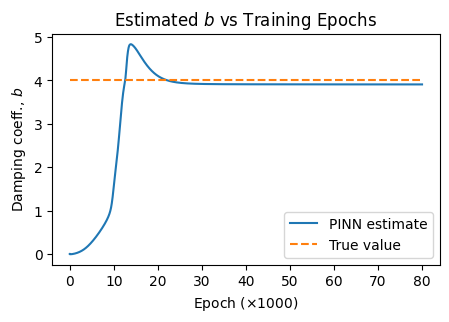

In [22]:
plt.figure(figsize=(5, 3))
plt.title("Estimated $b$ vs Training Epochs")
plt.plot(np.arange(n_epochs)/1000, b_cache, label="PINN estimate")
plt.plot([0, n_epochs/1000], [b, b], '--', label="True value")
plt.legend()
plt.xlabel("Epoch ($\\times 1000$)"); plt.ylabel("Damping coeff., $b$")
plt.show()

Likewise,

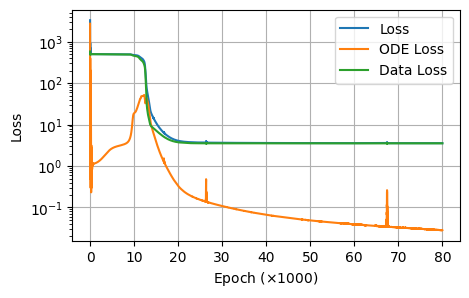

In [23]:
plt.figure(figsize=(5, 3))
plt.semilogy(np.arange(n_epochs)/1000, loss_cache, label=["Loss", "ODE Loss", "Data Loss"])
plt.legend()
plt.grid()
plt.xlabel("Epoch ($\\times 1000$)"); plt.ylabel("Loss")
plt.show()

In [24]:
print(f"ODE Loss: {loss_ode.item():.4f}")
print(f"Data Loss: {loss_obs.item():.4f}")
print(f"Total Loss: {loss.item():.4f}")
print(f"Estimated b: {b_param.item():.3f} (Correct b = {b})")

ODE Loss: 0.0283
Data Loss: 0.0024
Total Loss: 3.5624
Estimated b: 3.909 (Correct b = 4)


## Exercises

**Exercise 1:** Instead of using PINNs we could *discretise* the given ODE, and could estimate the parameters and system response by the maximum a posteriori (MAP) estimation method. How would you compare MAP estimation and PINNs?

**Exercise 2:** Investigate what happens as more observations are obtained or if fewer observations are available.

**Exercise 3:** Experiment with different NN structures (hidden layers).

**Exercise 4:** Experiment with [`torch.nn.Dropout`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html) as a way to regularise the neural network.

**Exercise 5:** Assume we have a fixed number of observations. The above methodology can be used to estimate $b$. Is this estimator unbiased? Compute an approximation of the variance of the estimation error.